# AP 155 Lab Exercise
---
## Exercise 6: Eigenfunctions and Eigenvalues of a Hamiltonian

_Instructions_: 
- **Problem 1 Report figure:** First 5 wavefunctions of the harmonic oscillator.
- **Problem 2 Report figure:** Energy analysis and plotting of probability density.
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Agbay, Tristan Michael 
- _Student No._: 2024-00281
- _Section_: THU-WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

<!-- ### Report figure

<img src="figures/cat.jpg" alt="Alt text" width=45%> <img src="figures/cat.jpg" alt="Alt text" width=45%>


EDIT ME. See instruction above for what to include. Insert caption here, a short description what the figure illustrates. The syntax in markdown for putting a figure is `![Description](local_file_name.png)` or `<img src="/path/to_image.jpg" alt="Alt text" width=45%>`. Make sure the figure has complete elements.
-->

### Report discussion

EDIT ME. See instruction above for what to include. Insert your discussions here. Discuss your key results with at most 150 words per question.

### Other comments
- None


---
## Section 2: Code

### Problem 1: Hamiltonian Matrix and its Eigs

The time-independent Schrödinger equation is:

$$
\left[-\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2}+\hat{V}(x)\right]\psi(x)=\left[\hat{T} + \hat{V} \right]\psi=E_n\psi(x).
$$

In quantum mechanics, we can represent operators (e.g. $\hat{T}$ and $\hat{V}$) as matrices, while the quantum state (in this case, $\psi$) is written as an $N \times 1$ vector

$$ \psi = 
\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix}
$$

where $\psi_i$ represents the value of the wave function at $x_i$. Now, we know that $\left[\hat{V}(x)\psi(x)\right]|_{x_i} \equiv V(x_i)\psi(x_i) = V_i \psi_i$. We can write this statement as:

$$\hat{V}
\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix} = 
\begin{bmatrix}
V_1\psi_1 \\
V_2\psi_2 \\
\vdots \\
V_i\psi_i \\
\vdots \\
V_N\psi_N
\end{bmatrix}
$$

This relation only holds true when $\hat{V}$ is an $N \times N$ square diagonal matrix of the form:

$$
\boxed{\hat{V}=
\begin{pmatrix}
V_1 & 0 & 0 & \cdots & 0 & 0 & 0 \\
0 & V_2 & 0 & \cdots & 0 & 0 & 0 \\
0 & 0 & V_3 & \cdots & 0 & 0 & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots & \vdots & \vdots \\
0 & 0 & 0 & \cdots & V_i & 0 & 0 \\
0 & 0 & 0 & \cdots & 0 & \ddots & 0 \\
0 & 0 & 0 & \cdots & 0 & 0 & V_N
\end{pmatrix}
}
$$

where $V_i$ denotes the potential's value at $x_i$. This is then what we call the "matrix representation" of the operator $\hat{V}$! At least, in the position basis -- more info on 142 or 241 :)

**(a)** On a piece of paper, find the matrix representation of the kinetic energy operator $\hat{T} \equiv \cfrac{-\hbar^2}{2m}\cfrac{\partial^2}{\partial x^2}$. Use the fact that 

$$
f''(x_i)=
\frac{f(x_{i+1}) - 2f(x_i) + f(x_{i-1})}{(\Delta x)^2}
$$

The first step of this problem would be to solve
$$
\cfrac{\partial^2}{\partial x^2}\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix} = \ ?
$$

and then to find a matrix representation for $\cfrac{\partial^2}{\partial x^2}$ operator. Your result should look like a square diagonal matrix

$$
\boxed{\hat{T}=
-\frac{\hbar^2}{2m(\Delta x)^2}
\begin{pmatrix}
-2 & 1 & 0 & 0 & 0 & \cdots & 0 \\
1 & -2 & 1 & 0 & 0 & \cdots & 0 \\
0 & 1 & -2 & 1 & 0 & \cdots & 0 \\
0 & 0 & 1 & -2 & 1 & \ddots & \vdots \\
0 & 0 & 0 & 1 & -2 & \ddots & 0 \\
\vdots & \vdots & \vdots & \ddots & \ddots & \ddots & 1 \\
0 & 0 & 0 & \cdots & 0 & 1 & -2
\end{pmatrix}
}
$$

**(b)** Write a function that outputs the Hamiltonian ($\hat{T} + \hat{V})$ matrix `hamiltonian(x_pos, potential_array, mass)` where `x_pos` and `potential_array` are both $N \times 1$ arrays (vectors), while `mass` is a scalar. The former represents position coordinates while the latter represents potential values at these coordinates. You might want to use `np.eye()`.

**(c)** Test your `hamiltonian()` function for the case where $V(x) = \cfrac{1}{2}m\omega^2x^2$. Obtain the first $N=5$ eigenfunctions of your Hamiltonian using `np.linalg.eigh()`, and obtain their corresponding eigenvalues. Plot the eigenfunctions, then offset each to its corresponding eigenvalue. In essence, you will plot $f_n$ where

$$
f_n = \psi_n + E_n
$$

Lastly, overlay the harmonic potential $V$ on the plot itself. Assume that $m=\hbar=1$ while $\omega=0.8$. 

Energy Eigenvalues: [  0.49972828   1.50096152   2.51823121   3.59367033   4.79297075
   6.17594292   7.77501261   9.59927448  11.64640272  13.90965187
  16.38046116  19.04926239  21.90572467  24.93884007  28.13696853
  31.48787539  34.97877019  38.59634904  42.32684039  46.15605371
  50.06943079  54.05209903  58.08892637  62.16457747  66.26357099
  70.37033736  74.46927707  78.54481899  82.58147851  86.56391515
  90.47698944  94.30581859  98.03583058 101.65281628 105.14297882
 108.49297947 111.68997873 114.72167053 117.57630645 120.24270394
 122.71022785 124.96872323 127.00835195 128.81921701 130.39048391
 131.70562959 132.77992439 133.31675839 134.79963478 134.80899882]


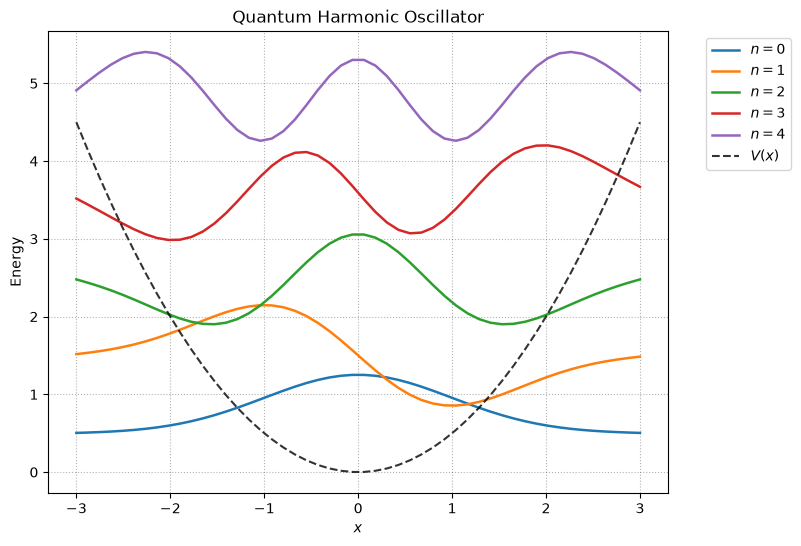

In [61]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("default")


def build_hamiltonian(x_pos, potential_array, particle_mass, h_bar=1):
    grid_size = len(x_pos)
    delta_x = x_pos[1] - x_pos[0]

    # tridiagonal kinetic energy matrix
    diag_main = -2.0 * np.eye(grid_size)
    diag_upper = np.eye(grid_size, k=1)
    diag_lower = np.eye(grid_size, k=-1)

    kinetic_matrix = (
        -(h_bar**2)
        / (2 * particle_mass * delta_x**2)
        * (diag_main + diag_upper + diag_lower)
    )

    # diagonal potential energy matrix
    potential_matrix = np.diag(potential_array)

    return kinetic_matrix + potential_matrix


# constants
m = 1
w = 1
x_vals = np.linspace(-3, 3, 50)
dx = x_vals[1] - x_vals[0]

# Define harmonic potential
V_vals = 0.5 * m * w**2 * x_vals**2

# Solve for eigenvalues and eigenvectors
H_matrix = build_hamiltonian(x_vals, V_vals, m)
evals, evecs = np.linalg.eigh(H_matrix)


plt.figure(figsize=(8, 6))

for i in range(5):
    psi = evecs[:, i]
    # Normalize the wave function
    psi_norm = psi / np.sqrt(np.sum(np.abs(psi) ** 2) * dx)
    # Ensure consistent phase for plotting and shift by energy level
    plt.plot(x_vals, -psi_norm + evals[i], linewidth=1.8, label=f"$n={i}$")

plt.plot(
    x_vals,
    V_vals,
    color="black",
    linestyle="--",
    alpha=0.8,
    linewidth=1.5,
    label="$V(x)$",
)

print("Energy Eigenvalues:", evals[:50])
plt.xlabel("$x$")
plt.ylabel("Energy")
plt.title("Quantum Harmonic Oscillator")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

# Explicitly set black grid lines
plt.grid(True, color="black", linestyle=":", alpha=0.3)

plt.savefig("QHOscillator.png", dpi=300, bbox_inches="tight")
plt.show()

#### Problem 1 code summary

Finite-difference approximation for the kinetic energy and potential energy (matrix) was used to construct the Hamiltonian (T + V) of a 1-D quantum harmonic oscillator. Afterwards, I utilized the np.linalg.eigh() in order to normalize and obtain the first five eigenfunctions and their energy eigenvalues, and I also printed the eigenvalues up to n = 50. Lastly, the potential associated with the harmonic oscillator is plotted together with the aforementioned eigenfunctions and eigenvalues.


---

### Problem 2: Harmonic Oscillator in an Electric Field

The effective potential of an oscillator immersed in a uniform electric field is

$$
V(x) = \cfrac{1}{2}m\omega^2x^2 + qEx
$$

where $q$ is the particle's charge, and $E$ is the strength of the applied uniform electric field.

**(a)** Assume that the particle is an electron and it is immersed in a field of strength $E=q^{-1}$. Plot 100 eigenenergies of the resulting Hamiltonian, and compare it with the theoretical value of

$$
E_n = \hbar \omega \left(n+\cfrac{1}{2} \right) - \cfrac{q^2 E^2}{2m \omega^2}
$$

Did you get the expected result? Why or why not?

**(b)** Plot the potential and the probability density of the ground state. Does the plot make sense? 

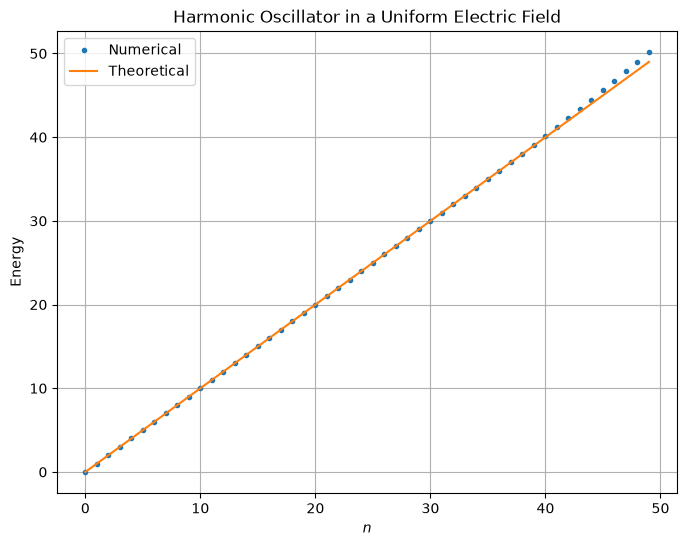

In [62]:
import numpy as np
import matplotlib.pyplot as plt


# Constants 
charge_q = 1
e_field = 1 / charge_q
x_vals_ext = np.linspace(-10, 10, 1000)


V_eff = 0.5 * m * w**2 * x_vals_ext**2 + charge_q * e_field * x_vals_ext

# Solve for eigenvalues and eigenvectors with the new potential
H_field = build_hamiltonian(x_vals_ext, V_eff, m)
evals_field, evecs_field = np.linalg.eigh(H_field)

# Extract first 50 energy levels and calculate theoretical equivalents
numerical_E = evals_field[:50]
n_states = np.arange(50)
theoretical_E = (1 * w * (n_states + 0.5)) - ((charge_q**2 * e_field**2) / (2 * m * w**2))

# Figure 1
plt.figure(figsize=(8, 6))
plt.plot(n_states, numerical_E, "o", markersize=3, label="Numerical")
plt.plot(n_states, theoretical_E, label="Theoretical")
plt.xlabel("$n$")
plt.ylabel("Energy")
plt.title("Harmonic Oscillator in a Uniform Electric Field")
plt.legend()
plt.grid(True)
plt.savefig("HO_UEF.png", dpi=300, bbox_inches="tight")
plt.show()

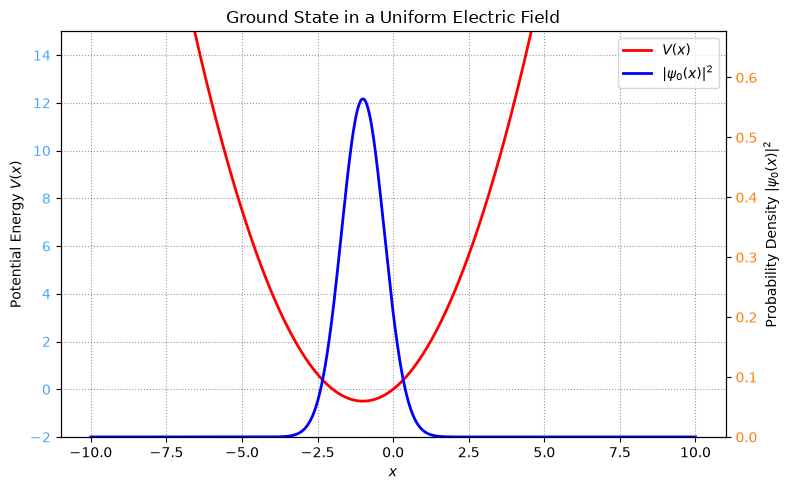

1.0


In [64]:
# Figure 2

# Continuous probability density normalization 
ground_state_psi = evecs_field[:, 0]
dx = x_vals_ext[1] - x_vals_ext[0]  # Ensure step size matches x_vals_ext
prob_density = (np.abs(ground_state_psi) ** 2) / dx

fig, ax1 = plt.subplots(figsize=(8, 5))

# left y-axis: Potential Energy V(x)
ax1.plot(x_vals_ext, V_eff, color="red", linewidth=2, label=r"$V(x)$")
ax1.set_xlabel(r"$x$")
ax1.set_ylabel(r"Potential Energy $V(x)$", color="black")
ax1.tick_params(axis="y", labelcolor="#4da6ff")
ax1.set_ylim(-2, 15)  # Zoomed to emphasize the bottom of the well
ax1.grid(True, color="black", linestyle=":", alpha=0.4)

# right y-axis: Ground State Probability Density
ax2 = ax1.twinx()
ax2.plot(x_vals_ext, prob_density, color="blue", linewidth=2, label=r"$|\psi_0(x)|^2$",)
ax2.set_ylabel(r"Probability Density $|\psi_0(x)|^2$", color="black")
ax2.tick_params(axis="y", labelcolor="#ff7f0e")
ax2.set_ylim(0, max(prob_density) * 1.2)

# Combined Legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")

plt.title("Ground State in a Uniform Electric Field")
fig.tight_layout()
plt.savefig("GroundState.png", dpi=300, bbox_inches="tight")
plt.show()

# to check if the prob density is truly equal to 1 (spoiler, it is 1 (yey!))
integral = np.sum(prob_density * dx)
print(integral)

#### Problem 2 code summary

The code calculates the Hamiltonian of a harmonic oscillator in a uniform electric field. The first 50 energy levels are computed and compared with theoretical values using np.linalg.eigh(). Finally, the ground-state eigenfunction is used to plot the probability density and the shifted potential.

---

## Section 3 (Notes)

### Some codes for solving matrix problems

* solving matrix equations ($\bf{A}\vec{x} = \vec{b}$) -> `np.linalg.solve`
* LU-decomposition ($\bf{A} = \bf{L}\bf{U}$) -> `scipy.linalg.lu`
* matrix inversion ($\bf{A}^{-1}$) -> `np.linalg.inv`
* QR-decomposition ($\bf{A} = \bf{Q}\bf{R}$) -> `scipy.linalg.qr`
* eigenvalue problem ($\bf{A}\vec{x} = \lambda \vec{x}$) -> `np.linalg.eig`

Solving matrix problems by themselves isn't difficult. There is an abundance of linear algebra libraries that are ready to use: from the battle-tested ones (the classic [BLAS](https://www.netlib.org/blas/) and [LAPACK](https://www.netlib.org/lapack/)), HPC tools for large problems ([ScaLAPACK](https://netlib.org/scalapack/)), to hardware-accelerated ones often with GPUs ([cuBLAS](https://docs.nvidia.com/cuda/cublas/index.html) and [cuSolver](https://docs.nvidia.com/cuda/cusolver/index.html) for NVIDIA). 

The hardest part is actually composing the matrix. How do you transform a physical problem into a linear algebra problem?

* Circuit: https://personal.math.vt.edu/embree/cmda3606/chapter2.pdf
* Embree [main notes](https://personal.math.vt.edu/embree/cmda3606notes.pdf) + [lab manual](https://personal.math.vt.edu/embree/labman.pdf)